# **EXPLORAÇÃO, ANÁLISE E TRATAMENTO DOS DADOS: PROJETO PREVISÃO DE DOENÇA CARDÍACA**

Este projeto tem por objetivo desenvolver um algoritmo de Machine Learning para prever a tendência de uma pessoa desenvolver algum tipo de doença cardíaca com base em alguns fatores clínicos e laboratoriais de referência. 

Os dados foram extraídos do site do Kaggle:

https://www.kaggle.com/fedesoriano/heart-failure-prediction/version/1

In [139]:
import pandas as pd
import numpy as np

In [140]:
# Carregar o dataset
dados = pd.read_csv('data/heart.csv')

## **Análise Exploratória de Dados (EDA)**

In [141]:
dados.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [142]:
dados.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [143]:
# Verificar valores nulos
dados.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### **Análise das Variáveis (Atributos)**

#### **Age = Idade** ####

In [144]:
dados['Age'].value_counts()

Age
54    51
58    42
55    41
56    38
57    38
52    36
62    35
59    35
51    35
53    33
60    32
48    31
61    31
63    30
50    25
41    24
43    24
46    24
64    22
49    21
65    21
47    19
44    19
45    18
42    18
38    16
67    15
39    15
40    13
69    13
66    13
37    11
35    11
68    10
74     7
70     7
34     7
36     6
32     5
71     5
72     4
75     3
29     3
31     2
33     2
77     2
76     2
30     1
28     1
73     1
Name: count, dtype: int64

In [145]:
dados['Age'].value_counts().sort_index()

Age
28     1
29     3
30     1
31     2
32     5
33     2
34     7
35    11
36     6
37    11
38    16
39    15
40    13
41    24
42    18
43    24
44    19
45    18
46    24
47    19
48    31
49    21
50    25
51    35
52    36
53    33
54    51
55    41
56    38
57    38
58    42
59    35
60    32
61    31
62    35
63    30
64    22
65    21
66    13
67    15
68    10
69    13
70     7
71     5
72     4
73     1
74     7
75     3
76     2
77     2
Name: count, dtype: int64

In [146]:
import plotly.express as px

In [147]:
hist1 =  px.histogram (dados,  x = "Age", nbins=60) 
hist1.update_layout(width=800,height=500,title_text='Distribuição das idades') 
hist1.show()

In [148]:
import seaborn as sns

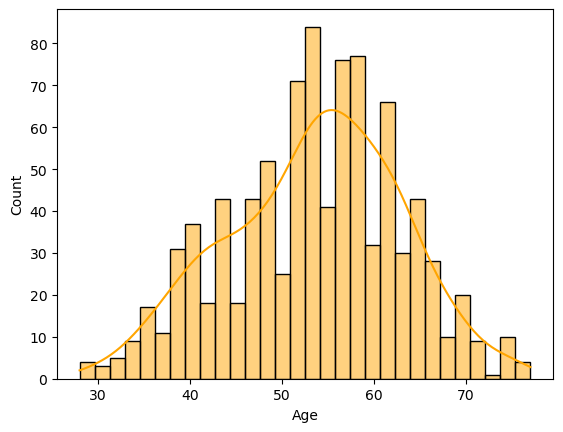

In [149]:
sns.histplot(dados, x='Age', bins=30, color="orange", kde=True, stat="count");

#### **Sex = Sexo**

In [150]:
dados['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

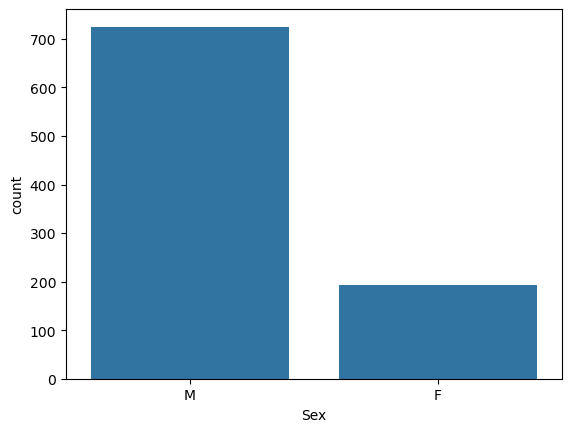

In [151]:
sns.countplot(x='Sex', data=dados);

#### **Chest Pain Type = tipo de dor no peito**

In [152]:
dados['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

#### **Resting BP (blood pressure) = pressão sanguínea em repouso em mmHg(sistólica)**

In [153]:
dados.RestingBP.value_counts().sort_index()

RestingBP
0       1
80      1
92      1
94      2
95      6
       ..
180    12
185     1
190     2
192     1
200     4
Name: count, Length: 67, dtype: int64

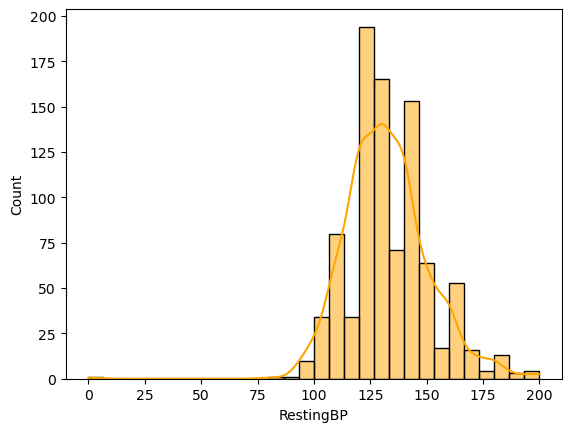

In [154]:
sns.histplot(dados, x='RestingBP', bins=30, color="orange", kde=True, stat="count");

#### **Cholesterol = colesterol sérico (mg/dl)**

In [155]:
dados.Cholesterol.value_counts().sort_index()

Cholesterol
0      172
85       1
100      2
110      1
113      1
      ... 
491      1
518      1
529      1
564      1
603      1
Name: count, Length: 222, dtype: int64

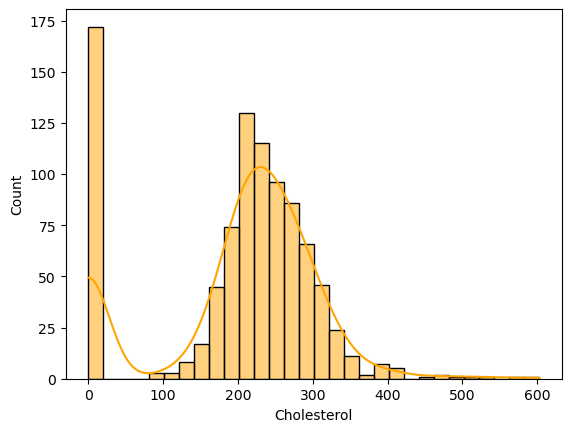

In [156]:
sns.histplot(dados, x='Cholesterol', bins=30, color="orange", kde=True, stat="count");

#### **Fasting BS (blood sugar) = açúcar no sangue em jejum (mg/dl)**

In [157]:
dados.FastingBS.value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

0: Fasting BS < 120 mg/dl (não diabético)

1: Fasting BS >= 120 mg/dl, (diabético)

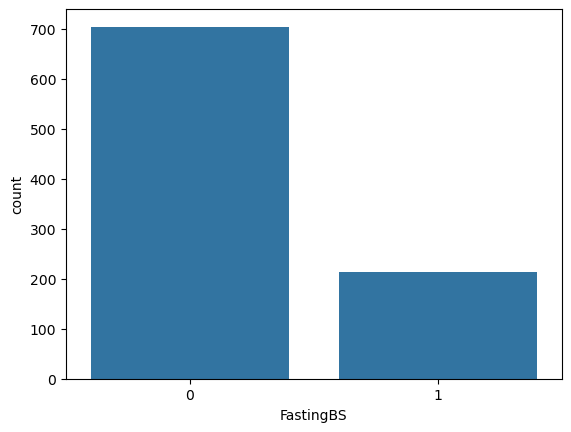

In [158]:
sns.countplot(x='FastingBS', data=dados);

#### **Resting ECG = eletrocardiograma em repouso**

In [159]:
dados.RestingECG.value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Normal: Normal

LVH: Hipertrofia ventricular esquerda

ST: Anormalidade da onda ST-T

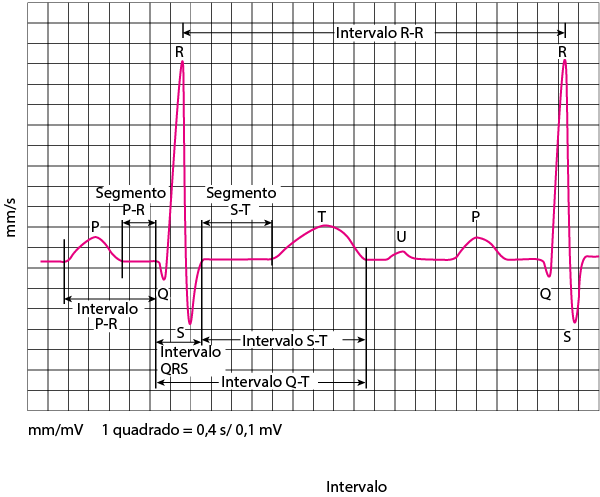

#### **Max HR (heart rate) = frequência cardíaca máxima**

In [160]:
dados['MaxHR'].value_counts()

MaxHR
150    43
140    41
120    36
130    33
160    25
       ..
192     1
195     1
194     1
187     1
202     1
Name: count, Length: 119, dtype: int64

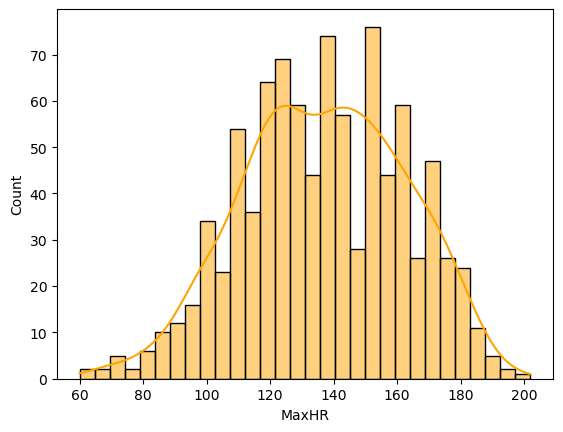

In [161]:
sns.histplot(dados, x='MaxHR', bins=30, color="orange", kde=True, stat="count");

#### **Exercise Angina = Angina induzida por exercício**

In [162]:
dados['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [163]:
px.pie(dados, 'ExerciseAngina') 

#### **Old Peak = Depressão de ST (referência no ECG) induzida por exercício em relação ao repouso**

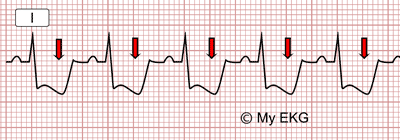

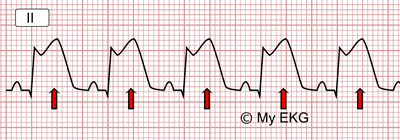

In [164]:
dados['Oldpeak'].value_counts()

Oldpeak
 0.0    368
 1.0     86
 2.0     76
 1.5     53
 3.0     28
 1.2     26
 0.2     22
 0.5     19
 1.4     18
 1.8     17
 2.5     16
 1.6     16
 0.8     16
 0.1     14
 0.6     14
 0.3     11
 0.4     11
 4.0      8
 2.8      7
 0.7      7
 1.3      7
 1.1      7
 2.6      7
 1.9      7
 1.7      6
 2.2      5
 3.6      4
 0.9      4
 2.4      4
 3.4      3
 2.1      2
 3.2      2
 2.3      2
-1.0      2
 4.2      2
 3.5      2
-0.1      2
-0.5      2
 5.0      1
-0.7      1
-0.8      1
-1.5      1
-0.9      1
-2.6      1
-1.1      1
 3.7      1
-2.0      1
 3.1      1
 5.6      1
 3.8      1
 2.9      1
 6.2      1
 4.4      1
Name: count, dtype: int64

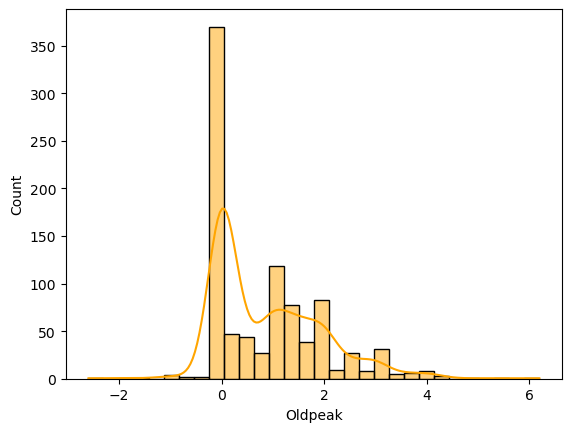

In [165]:
sns.histplot(dados, x='Oldpeak', bins=30, color="orange", kde=True, stat="count");

#### **ST_Slope = Inclinação do segmento ST no ECG**

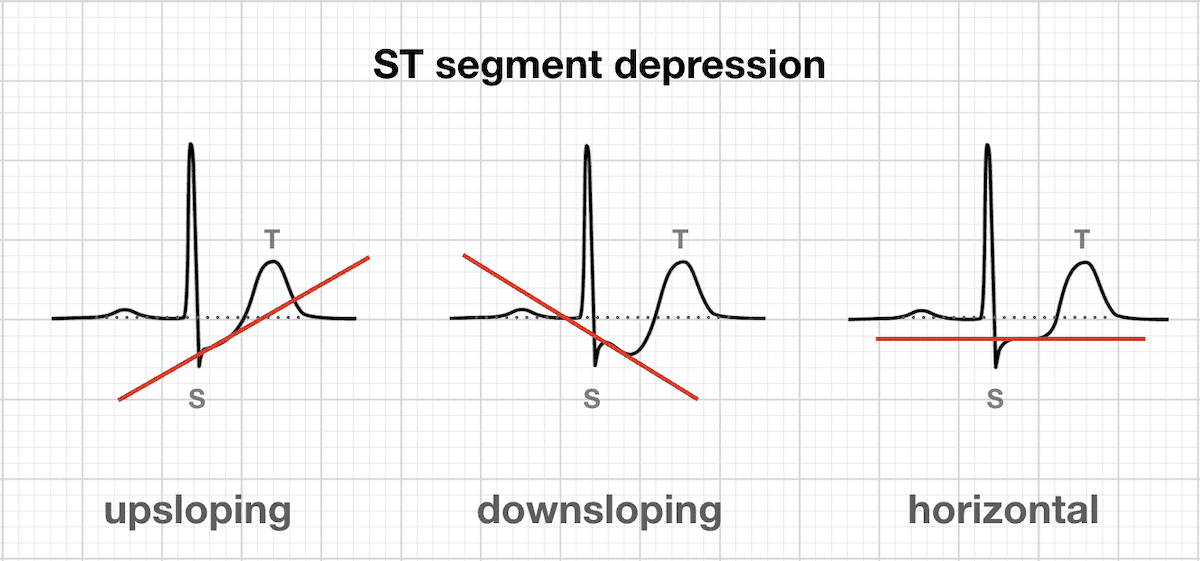

In [166]:
dados['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

Flat = plano

Up = para cima

Down = para baixo 

In [167]:
px.pie(dados, 'ST_Slope') 

#### **Heart Disease = Doença cardíaca**

In [168]:
dados['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

0 = Não possui doença cardíaca

1 = Possui doença cardíaca



In [169]:
px.pie(dados, 'HeartDisease')

**Análise dos atributos**

In [170]:
dados.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [171]:
dados.mode()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,54,M,ASY,120,0,0,Normal,150,N,0.0,Flat,1


### **Tratando Valores Incoerentes**

**Excluindo registros com pressão zero**

In [172]:
dados2 = dados.loc[dados["RestingBP"] != 0]

In [173]:
dados2.shape

(917, 12)

**Substituindo valores zeros do Colesterol pela média sem os zeros**

In [174]:
dados2.Cholesterol.mean()

np.float64(199.0163576881134)

In [175]:
dados2.loc[dados2['Cholesterol'] == 0, 'Cholesterol'] = np.nan

In [176]:
dados2.Cholesterol.mean()

np.float64(244.6353887399464)

In [177]:
# Substituindo os valores nulos pela média
# Substituindo os valores nulos pela média
dados2['Cholesterol'] = dados2['Cholesterol'].fillna(dados2['Cholesterol'].mean())

/tmp/ipykernel_130738/2470138115.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [178]:
dados2.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [179]:
dados2.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,244.635389,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,53.347125,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,244.635389,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [180]:
dados2.mode()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,54,M,ASY,120,244.635389,0,Normal,150,N,0.0,Flat,1


## **Salvando (Exportando) o Dataframe Tratado**

In [181]:
dados2.to_csv('heart_tratado.csv', sep=';', encoding='utf-8', index = False)

In [182]:
dados2.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,244.635389,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,53.347125,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,244.635389,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


#### **Análise de Outliers**

In [183]:
# Idade
px.box(dados2, y='Age')

In [184]:
# Pressão Sanguínea em Repouso
px.box(dados2, y='RestingBP')

In [185]:
# Colesterol
px.box(dados2, y='Cholesterol')

In [186]:
# Frequência Cardíaca Máxima
px.box(dados2, y='MaxHR')

## **Salvando (Exportando) o Dataframe Tratado**

In [187]:
dados2.to_csv('data/heart_tratado.csv', sep=';', encoding='utf-8', index = False)